# ペアトレードとバージョン固定されたデータの背骨

実際の価格を使った共和分ペア戦略です。Engle-Granger 検定で候補ペアを走査し、ローリングの
ヘッジ比率を組み、スプレッドの z スコアをウィンドウ関数で*SQL の中で*計算し、シグナルを
ずらしてコストを引いたバックテストにかけます。

h5i-db ならではの仕掛けは最後に来ます。価格を2回のコミットに分けて読み込むので、
パイプライン全体を `h5i('prices', v_early)`、つまり過去の研究が見ていたはずのテーブルに
対して走らせ直せます。結果が固定されるのは、ベンダーファイルの今日の中身ではなく、データの
バージョンです。

このレシピで進めるのは次の5つです。

1. 意味のある2回のコミットに分けて価格を読み込む
2. 候補ペア3組の共和分を走査する
3. ローリングのヘッジ比率を組み、スプレッドをそれ自体のテーブルとして保存する
4. z スコアをデータベースの中で計算し、正直にバックテストする
5. 研究全体を過去のデータバージョンに対して走らせ直す

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, sql_expr
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_pairs"), create=True)

## 1. データ

モメンタムのレシピと同じ、`cu.fetch_daily` の30銘柄の日足キャッシュです。1行が1銘柄
1セッションです。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | セッションの日付 |
| `symbol` | `string` | 銘柄コード |
| `open`、`high`、`low`、`close` | `float64` | セッションの価格 |
| `adj_close` | `float64` | 分割と配当で調整済みの終値 |
| `volume` | `int64` | 出来高（株数） |

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
print(f"{daily.num_rows:,} rows x {daily.num_columns} columns, "
      f"{len(set(daily['symbol'].to_pylist()))} symbols")
daily.to_pandas().head()

64,020 rows x 8 columns, 30 symbols


,ts,symbol,open,high,low,close,adj_close,volume
0,2018-01-02 20:00:00+00:00,AAPL,42.540001,43.075001,42.314999,43.064999,40.267075,102223600
1,2018-01-02 20:00:00+00:00,NVDA,4.894500,4.987500,4.862500,4.983750,4.922529,355616000
2,2018-01-02 20:00:00+00:00,GE,84.251045,86.215950,84.011429,86.168022,80.953125,16185981
3,2018-01-02 20:00:00+00:00,AMZN,58.599998,59.500000,58.525501,59.450500,59.450500,53890000
4,2018-01-02 20:00:00+00:00,IBM,147.705551,148.001907,146.787766,147.466537,102.657249,4395815


読み込みは 2025-01-01 でわざと分けます。最初の `append` が、仮想的な2024年の研究が走った
テーブル。2つ目が現在まで持ってくるぶんです。

`append` はそれぞれアトミックなコミット1件で、`versions()` は両方を永久に保持します。

In [3]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("adj_close", pa.float64()),
    ]
)
db.create_table("prices", schema, time_column="ts", sort_key=["ts", "symbol"])

prices = (
    daily.select(["ts", "symbol", "adj_close"])
    .sort_by([("ts", "ascending"), ("symbol", "ascending")])
    .cast(schema)
)
cutoff = pd.Timestamp("2025-01-01", tz="UTC")
mask = pa.compute.less(prices["ts"], pa.scalar(cutoff, type=pa.timestamp("us", tz="UTC")))

c1 = db.append("prices", prices.filter(mask), note="history through 2024")
v_early = c1["sequence"]
c2 = db.append("prices", prices.filter(pa.compute.invert(mask)), note="2025 onwards")
print(f"v{v_early}: {c1['rows_total']:,} rows   v{c2['sequence']} (head): {c2['rows_total']:,} rows")

v1: 52,830 rows   v2 (head): 64,020 rows


## 2. 共和分の走査

ユニバースから経済的に筋の通る候補を3組。KO/PEP、GS/JPM、CVX/XOM です。素の SQL 走査で
対数調整終値を引き、それぞれに `statsmodels` の Engle-Granger 検定をかけます。

相関しているのと共和分しているのは別の話です。p 値が検定しているのは*スプレッド*が定常か
どうかで、平均回帰に本当に要るのはそちらです。

In [4]:
from statsmodels.tsa.stattools import coint

CANDIDATES = [("KO", "PEP"), ("GS", "JPM"), ("CVX", "XOM")]

def log_prices(symbols, version=None):
    """Log closes for a symbol set, from any version of `prices`."""
    return (
        db.table("prices", version=version)
        .filter(col("symbol").is_in(symbols))
        .select("ts", "symbol", log_px=col("adj_close").log())
        .sort(["ts", "symbol"])
        .to_pandas()
        .pivot(index="ts", columns="symbol", values="log_px")
    )


logpx = log_prices(["KO", "PEP", "GS", "JPM", "CVX", "XOM"])

scan = pd.DataFrame(
    [
        {
            "pair": f"{a}/{b}",
            "corr": logpx[a].diff().corr(logpx[b].diff()),
            "coint_p": coint(logpx[a], logpx[b])[1],
        }
        for a, b in CANDIDATES
    ]
).set_index("pair")
scan.round(4)

,corr,coint_p
pair,,
KO/PEP,0.7130,0.9898
GS/JPM,0.8093,0.5448
CVX/XOM,0.8426,0.0196


5% の閾値を越えるのは CVX/XOM だけです。教科書に載っているペアである KO/PEP は越えません。
リターンの相関は高いのに、スプレッドがトレンドを持つからです。

これは走査の結果としてはよくあることで、体に入れておく価値があります。「見るからにペア」の
ほとんどは定常性の検定に落ちます。ここでは CVX/XOM を取引します。

## 3. ローリングのヘッジ比率とスプレッド

ヘッジ比率は、対数 CVX に対する対数 XOM の252日ローリング OLS ベータです。共分散を分散で
割るかたちで、ベクトル化しただけの同じものです。

スプレッド `log(XOM) - beta*log(CVX)` とそのベータは、それ自体の h5i テーブルに入れます。
こうするとシグナルの段が SQL で走りますし、スプレッドの系列がそれを生んだ価格と一緒に
バージョン管理されます。

In [5]:
lx, ly = logpx["CVX"], logpx["XOM"]
beta = ly.rolling(252).cov(lx) / lx.rolling(252).var()
spread = ly - beta * lx

spread_df = (
    pd.DataFrame({"ts": spread.index, "spread": spread.values, "beta": beta.values})
    .dropna()
    .reset_index(drop=True)
)
spread_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("spread", pa.float64()),
        pa.field("beta", pa.float64()),
    ]
)
db.create_table("spread", spread_schema, time_column="ts", sort_key=["ts"])
db.append(
    "spread",
    pa.Table.from_pandas(spread_df, preserve_index=False).cast(spread_schema),
    note="XOM vs CVX, rolling 252d OLS hedge",
)
len(spread_df)

1883

## 4. データベースの中の z スコア

売買シグナルは、60日の窓に対するスプレッドの z スコアです。
`.rolling_mean(60, order_by="ts")` と `.rolling_std(60, order_by="ts")` はそれぞれ、整列済み
ストレージの上のウィンドウ集約に落ちます。クエリ1つで済み、状態を持つバックテスト本体まで
pandas の `rolling()` は要りません。

これらの動詞は `partition_by=` を渡せば `PARTITION BY` を持ちます。SQL の `rolling_avg`
糖衣は決して持たないので、ここのような単一系列のテーブルでしか安全に使えません。

In [6]:
zs = (
    db.table("spread")
    .select(
        "ts", "spread", "beta",
        z=(col("spread") - col("spread").rolling_mean(60, order_by="ts"))
        / col("spread").rolling_std(60, order_by="ts"),
    )
    .sort("ts")
    .to_pandas()
)
zs = zs.set_index("ts")
zs.tail(3).round(4)

,spread,beta,z
ts,,,
2026-06-26 20:00:00+00:00,-1.7566,1.2978,-1.3445
2026-06-29 20:00:00+00:00,-1.7538,1.3004,-1.2953
2026-06-30 20:00:00+00:00,-1.7414,1.3031,-1.2108


## 5. バックテスト: |z| > 2 で入り、ゼロ交差で出る

出入りのルールは状態を持つので、小さな明示的ループを回します。2,000行なら一瞬です。

衛生管理の規則はこうです。

- ポジションは `shift(1)` で**前日の z** から決めるので、先読みはありません
- 日次の P&L は**ずらした**ヘッジ比率を使います。
  `pos[t-1] * (dlog XOM - beta[t-1] * dlog CVX)`。これは実際に持っていた本のリターンで
  あって、ベータが黙って組み替わったスプレッドのリターンではありません
- コストは片脚あたり取引金額の 10bps。ペアの往復はおよそ `2 * (1 + |beta|) * 10` bps です

In [7]:
z_lag = zs["z"].shift(1)
pos = np.zeros(len(zs))
p = 0.0
for i, z in enumerate(z_lag.fillna(0.0).to_numpy()):
    if p == 0.0:
        if z > 2:
            p = -1.0  # spread rich: short XOM, long beta*CVX
        elif z < -2:
            p = 1.0
    elif (p < 0 and z <= 0) or (p > 0 and z >= 0):
        p = 0.0
    pos[i] = p
pos = pd.Series(pos, index=zs.index, name="pos")

dlx = lx.diff().reindex(zs.index)
dly = ly.diff().reindex(zs.index)
beta_lag = zs["beta"].shift(1)
pair_ret = dly - beta_lag * dlx           # per unit of XOM leg
pnl_gross = pos.shift(1) * pair_ret
traded = pos.diff().abs().fillna(0.0) * (1 + beta_lag.abs())
pnl_net = (pnl_gross - 10 / 1e4 * traded).dropna()

equity = pnl_net.cumsum()
sharpe = pnl_net.mean() / pnl_net.std() * np.sqrt(252)
max_dd = (equity - equity.cummax()).min()
n_trades = int((pos.diff().abs() > 0).sum())
print(
    f"round turns: {n_trades // 2}   time in market: {(pos != 0).mean():.0%}\n"
    f"Sharpe (net): {sharpe:.2f}   total P&L: {equity.iloc[-1]:+.1%} (log, unit notional)\n"
    f"max drawdown: {max_dd:.1%}"
)

round turns: 16   time in market: 76%
Sharpe (net): 0.27   total P&L: +42.8% (log, unit notional)
max drawdown: -54.9%


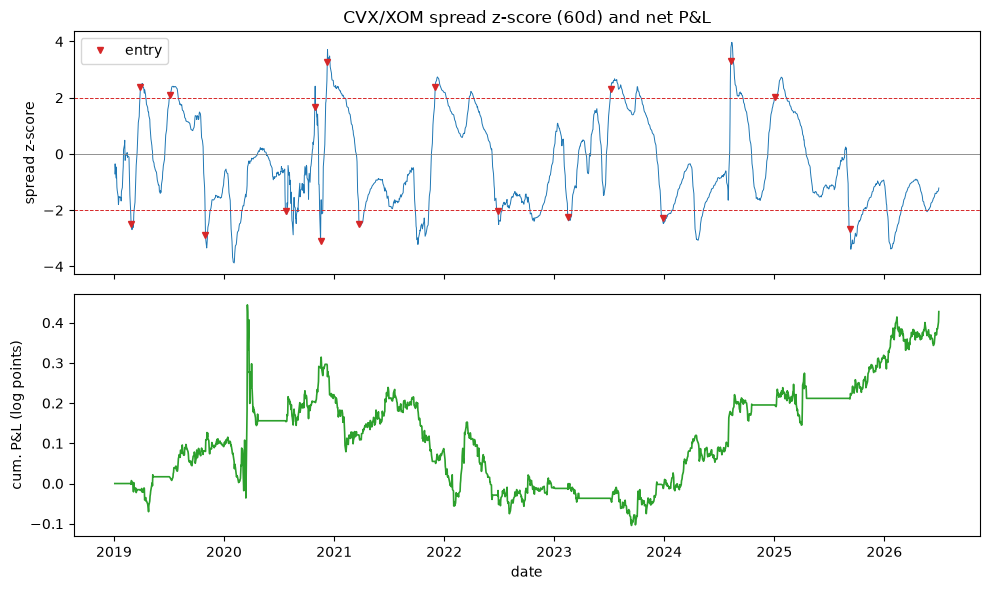

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(zs.index, zs["z"], lw=0.7, color="tab:blue")
axes[0].axhline(2, color="tab:red", lw=0.7, ls="--")
axes[0].axhline(-2, color="tab:red", lw=0.7, ls="--")
axes[0].axhline(0, color="gray", lw=0.6)
entries = pos[(pos.diff() != 0) & (pos != 0)].index
axes[0].plot(entries, zs.loc[entries, "z"], "v", color="tab:red", ms=5, label="entry")
axes[0].set_ylabel("spread z-score")
axes[0].set_title("CVX/XOM spread z-score (60d) and net P&L")
axes[0].legend(loc="upper left")
axes[1].plot(equity.index, equity, lw=1.2, color="tab:green")
axes[1].set_ylabel("cum. P&L (log points)")
axes[1].set_xlabel("date")
fig.tight_layout()

シャープは弱いプラス、ドローダウンは深い。開いていくスプレッドを平均まで持ち切るのが、
ペアの本が痛む典型的なやり方です。

ペアは1組、p 値はぎりぎり、ストップロスもなし。これは戦略というより手法のデモです。実際の
本なら多数のペアに分散し、発散リスクに上限を置きます。

## 6. シグナルを保存し、実行を固定する

ポジションと z スコアを `signals` テーブルに入れ、スナップショット1つで `prices`、
`spread`、`signals` をまとめて実行 ID の下に固定します。

In [9]:
sig_df = zs.reset_index()[["ts", "z"]].assign(pos=pos.values).dropna()
sig_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("z", pa.float64()),
        pa.field("pos", pa.float64()),
    ]
)
db.create_table("signals", sig_schema, time_column="ts", sort_key=["ts"])
db.append("signals", pa.Table.from_pandas(sig_df, preserve_index=False).cast(sig_schema))
db.snapshot("pairs-run-001", tables=["prices", "spread", "signals"], note="CVX/XOM |z|>2")
(
    db.table("signals", snapshot="pairs-run-001")
    .select(rows=count_star(), first=col("ts").min(), last=col("ts").max())
    .to_pandas()
)

,rows,first,last
0,1882,2019-01-03 20:00:00+00:00,2026-06-30 20:00:00+00:00


## 7. 過去のデータバージョンでパイプラインを走らせ直す

研究全体を、*`prices` のどのバージョンを読むか*でパラメータ化したものがこれです。読み取り点
は `db.table(...)` の引数です。クエリに埋め込む文字列ではないので、キーワード1つで済みます。
`run_pipeline(version=v_early)` です。

2025年より前のバージョンで走らせれば、2024年の研究が見つけたはずのものが再現します。同じ
バージョンで2回走らせればビット単位で一致します。ベンダーが足元で履歴を訂正してきたときに
効いてくる性質です。

In [10]:
def run_pipeline(version=None) -> dict:
    """Coint p-value + net Sharpe for CVX/XOM from any version of prices."""
    px = log_prices(["CVX", "XOM"], version=version)
    lx_, ly_ = px["CVX"], px["XOM"]
    b = ly_.rolling(252).cov(lx_) / lx_.rolling(252).var()
    s = ly_ - b * lx_
    z = ((s - s.rolling(60).mean()) / s.rolling(60).std()).shift(1)
    q = np.zeros(len(z))
    p_ = 0.0
    for i, v in enumerate(z.fillna(0.0).to_numpy()):
        if p_ == 0.0:
            if v > 2:
                p_ = -1.0
            elif v < -2:
                p_ = 1.0
        elif (p_ < 0 and v <= 0) or (p_ > 0 and v >= 0):
            p_ = 0.0
        q[i] = p_
    q = pd.Series(q, index=z.index)
    ret = q.shift(1) * (ly_.diff() - b.shift(1) * lx_.diff())
    net_ = (ret - 10 / 1e4 * q.diff().abs().fillna(0) * (1 + b.shift(1).abs())).dropna()
    return {
        "rows": len(px),
        "last_day": px.index[-1].date().isoformat(),
        "coint_p": round(coint(lx_, ly_)[1], 4),
        "sharpe_net": round(net_.mean() / net_.std() * np.sqrt(252), 3),
    }


runs = pd.DataFrame(
    {
        "head (today)": run_pipeline(),
        f"version {v_early}": run_pipeline(version=v_early),
        f"version {v_early} again": run_pipeline(version=v_early),
    }
).T
assert runs.iloc[1].equals(runs.iloc[2]), "same version must reproduce exactly"
runs

,rows,last_day,coint_p,sharpe_net
head (today),2134,2026-06-30,0.0196,0.282
version 1,1761,2024-12-31,0.0782,0.158
version 1 again,1761,2024-12-31,0.0782,0.158


2025年より前の実行は違う標本を見るので、p 値もシャープも変わります。そのピン留めした
バージョンで走らせ直せば、結果は厳密に再現します。「この数字はどのデータから出たのか」に、
バージョン番号という正確な答えがあるわけです。

## まとめ

- 実データに対する Engle-Granger は謙虚にさせてくれます。筋の通る候補3組のうち、5% で
  共和分していたのは CVX/XOM だけでした。相関は共和分ではありません。
- z スコアはすべて SQL で走りました。保存した `spread` テーブルに対する `rolling_mean` と
  `rolling_std` の動詞です。
- バックテストの正直さとは、ずらした z、P&L の中のずらしたヘッジ比率、そして片脚ごとの
  コストです。シャープは控えめでドローダウンは醜い。1組のペアの本とはそういうものです。
- 意味のある単位でコミットしておくと、あとで効いてきます。`h5i('prices', v)` はどんな研究も
  当時と同じバイト列に対して走らせ直しますし、`db.snapshot(...)` は3つのテーブルの状態を
  1つの名前でまとめて指せます。

In [11]:
db.close()